In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

# Load dataset
housing = fetch_california_housing()

# Convert to DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)

# Add target column
df["Price"] = housing.target

# Display first 5 rows
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [2]:
# Shape of dataset
print("Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Data types
print("\nData Types:")
print(df.dtypes)

Shape: (20640, 9)

Columns:
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'Price'],
      dtype='str')

Data Types:
MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      float64
Longitude     float64
Price         float64
dtype: object


In [3]:
# Check missing values
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

In [4]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


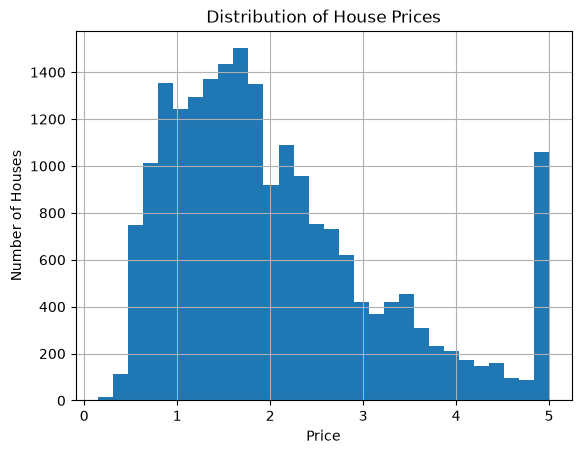

In [5]:
import matplotlib.pyplot as plt

df["Price"].hist(bins=30)

plt.title("Distribution of House Prices")

plt.xlabel("Price")

plt.ylabel("Number of Houses")

plt.show()

In [6]:
from sklearn.model_selection import train_test_split

# Features (input)
X = df.drop("Price", axis=1)

# Target (output)
y = df["Price"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (16512, 8)
Testing data: (4128, 8)


In [7]:
from sklearn.linear_model import LinearRegression

# Create the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("✅ Model trained successfully!")

✅ Model trained successfully!


In [8]:
# Predict on test data
predictions = model.predict(X_test)

print(predictions[:10])

[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725 2.01175367
 2.64550005 2.16875532 2.74074644 3.91561473]


In [9]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error:", mae)
print("R² Score:", r2)

Mean Absolute Error: 0.5332001304956555
R² Score: 0.575787706032451


In [10]:
import joblib

# Save the trained model
joblib.dump(model, "../models/house_price_model.pkl")

print("✅ Model saved successfully!")

✅ Model saved successfully!


In [11]:
import joblib

loaded_model = joblib.load("../models/house_price_model.pkl")

print("Model loaded successfully!")

Model loaded successfully!


In [13]:
import pandas as pd

sample_house = pd.DataFrame({
    "MedInc": [8.3],
    "HouseAge": [21.0],
    "AveRooms": [6.2],
    "AveBedrms": [0.97],
    "Population": [2400.0],
    "AveOccup": [2.1],
    "Latitude": [37.86],
    "Longitude": [-122.22]
})

prediction = loaded_model.predict(sample_house)

print(f"Predicted House Price: {prediction[0]:.2f}")

Predicted House Price: 4.00


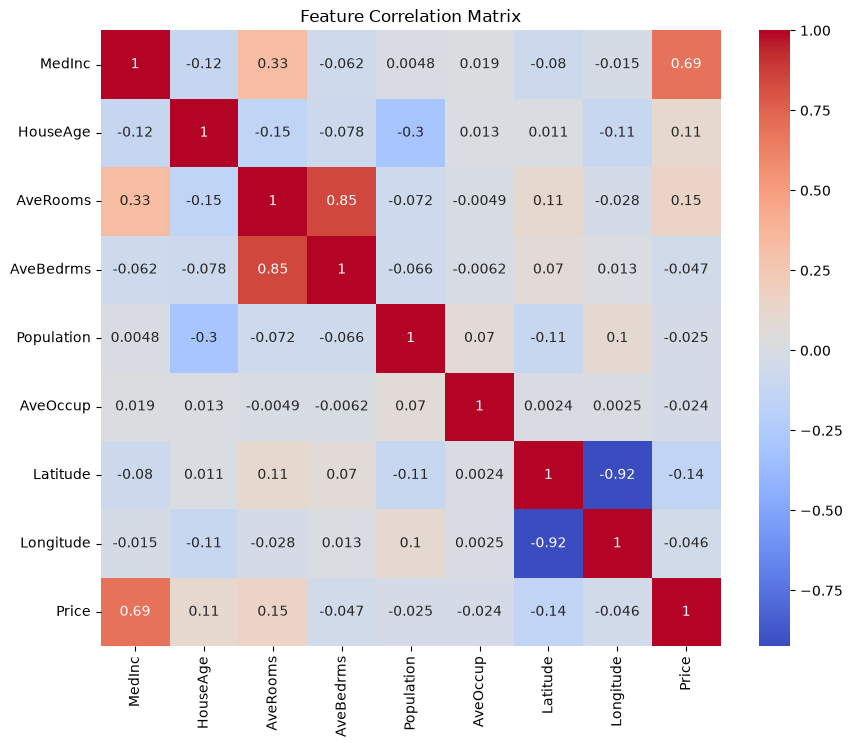

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Feature Correlation Matrix")

plt.show()

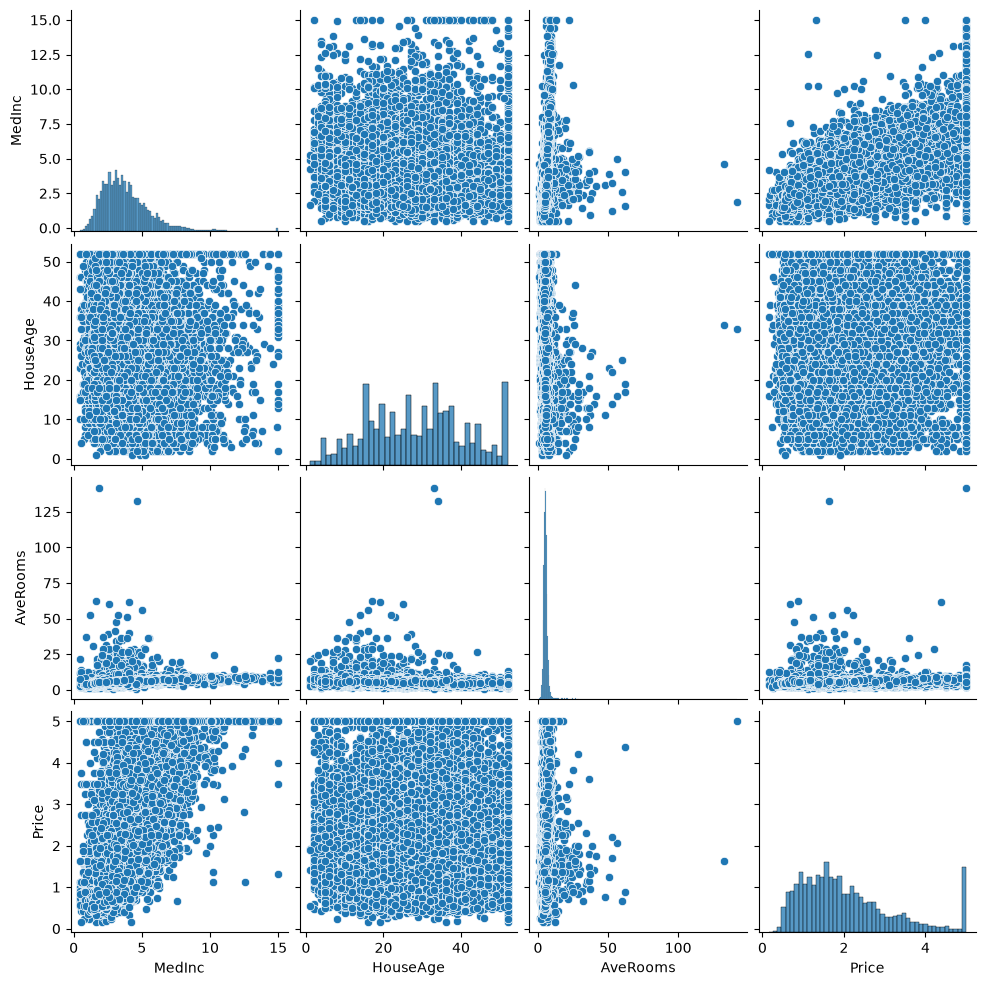

: 

In [ ]:
sns.pairplot(
    df[[
        "MedInc",
        "HouseAge",
        "AveRooms",
        "Price"
    ]]
)

plt.show()